In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import rcParams
rcParams['font.sans-serif']=['SimHei']#字体设计
df=pd.read_csv('hangzhou_house_data.csv')
#数据清理
print(len(df))
df.isna().sum()
df.dropna(inplace=True)
print(len(df))
print(df.duplicated().sum())
df.drop_duplicates(keep='first',inplace=True)
df.duplicated().sum()

30150
19110
97


np.int64(0)

In [5]:
df['朝向']=df['朝向'].astype('category')
df['楼层信息']=df['楼层信息'].astype('category')
df.info()
df.describe()

<class 'pandas.DataFrame'>
Index: 19013 entries, 3 to 29999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   成交编号       19013 non-null  str     
 1   城市         19013 non-null  str     
 2   区域         19013 non-null  str     
 3   楼盘名称       19013 non-null  str     
 4   户型         19013 non-null  str     
 5   套内面积(㎡)    19013 non-null  float64 
 6   建筑面积(㎡)    19013 non-null  float64 
 7   建筑年代       19013 non-null  float64 
 8   朝向         19013 non-null  category
 9   楼层信息       19013 non-null  category
 10  装修情况       19013 non-null  str     
 11  物业类型       19013 non-null  str     
 12  产权年限       19013 non-null  int64   
 13  成交总价(万元)   19013 non-null  float64 
 14  挂牌总价(万元)   19013 non-null  float64 
 15  成交单价(元/㎡)  19013 non-null  float64 
 16  带看次数       19013 non-null  int64   
 17  调价次数       19013 non-null  float64 
 18  成交周期(天)    19013 non-null  float64 
dtypes: category(2), float64(8), int64(2), str

,套内面积(㎡),建筑面积(㎡),建筑年代,产权年限,成交总价(万元),挂牌总价(万元),成交单价(元/㎡),带看次数,调价次数,成交周期(天)
count,19013.000000,19013.000000,19013.000000,19013.000000,19013.000000,19013.000000,19013.000000,19013.000000,19013.000000,19013.000000
mean,110.671100,130.037289,2006.980329,54.981855,314.481996,328.673857,28458.832588,19.581549,3.496029,92.455530
std,45.484742,53.679165,10.084841,15.000384,230.470677,241.054525,15986.225192,11.562213,2.279780,50.650108
min,32.000000,35.500000,1990.000000,40.000000,14.830000,15.150000,4431.000000,0.000000,0.000000,5.000000
25%,71.680000,84.000000,1998.000000,40.000000,143.240000,149.460000,14678.000000,10.000000,2.000000,49.000000
50%,110.460000,129.700000,2007.000000,40.000000,238.890000,249.410000,22069.000000,20.000000,3.000000,93.000000
75%,149.750000,175.410000,2016.000000,70.000000,424.060000,442.790000,45380.000000,30.000000,5.000000,136.000000
max,190.000000,237.100000,2024.000000,70.000000,1072.270000,1141.470000,59879.000000,39.000000,7.000000,179.000000


### 图注：本图为清洗后杭州二手房数据集描述性统计结果，展示套内面积、成交总价、建筑年代等数值特征的样本量、均值、标准差、最值与四分位数，用于快速了解各特征分布范围，为后续异常值识别提供基础。

In [6]:
print(df['楼层信息'].unique())
floor_map={
    '低楼层':1,
    '中楼层':2,
    '高楼层':3,
    '顶楼':4
}
df['楼层编码']=df['楼层信息'].map(floor_map)
print(df[['楼层信息','楼层编码']].head)


['中楼层', '低楼层', '顶楼', '高楼层']
Categories (4, str): ['中楼层', '低楼层', '顶楼', '高楼层']
<bound method NDFrame.head of       楼层信息 楼层编码
3      中楼层    2
4      低楼层    1
6       顶楼    4
7       顶楼    4
10     低楼层    1
...    ...  ...
29991  高楼层    3
29993   顶楼    4
29994   顶楼    4
29997  中楼层    2
29999  中楼层    2

[19013 rows x 2 columns]>


### 图注：本部分代码将文本类型楼层信息（低楼层、中楼层、高楼层、顶楼）映射转换为数字编码，把分类特征转为可参与相关性计算的数值特征，用于后续建模与特征分析。

Text(0.5, 1.0, '房屋特征相关性热力图')

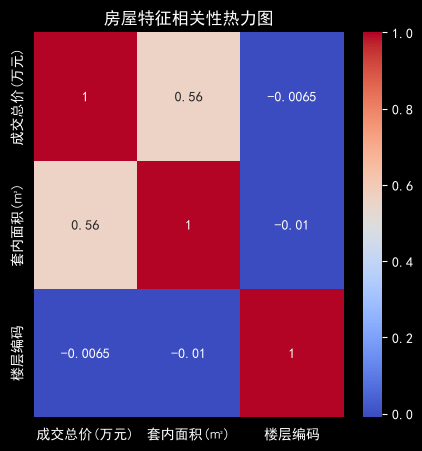

In [7]:

corr_matrix=df[['成交总价(万元)','套内面积(㎡)','楼层编码']].corr()
plt.figure(figsize=(5,5))#绘制热力图
sns.heatmap(corr_matrix,cmap='coolwarm',annot=True)
plt.title('房屋特征相关性热力图')

### 本图展示了成交总价、套内面积、楼层编码三个核心特征值之间的线性相关关系，通过相关关系数量化特征之间的关联强度与方向。

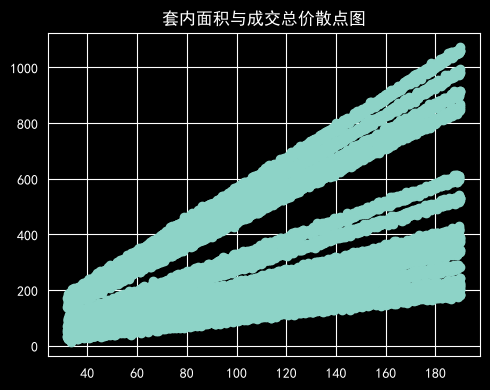

In [12]:
plt.figure(figsize=(5,4))
plt.scatter(data=df,x='套内面积(㎡)',y='成交总价(万元)')
plt.title('套内面积与成交总价散点图')
plt.tight_layout()
plt.show()

### 整体样本呈现从左下向右上发散的趋势：套内面积更大房屋成交总价整体更高，验证二者存在正相关关系。
### 点的分布呈多簇分层，说明同样面积下房价差异很大，除面积外还有其他因素在影响房价。
### 随着面积变大纵向散开的程度更大：面积越大，房价的离散程度更高。

<Axes: xlabel='成交总价(万元)', ylabel='Count'>

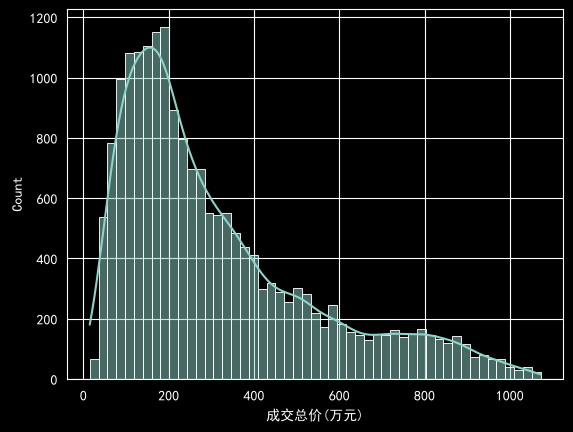

In [13]:
sns.histplot(data=df,x='成交总价(万元)',kde=True)

### 房价出现明显右偏分布，峰值出现在左侧，大量房源集中在中低总价区间；向右侧高价区间，样本数量逐步变少。
### 大多数二手房集中在中低总价区间，属于刚需、普通改善房源；高价房源样本数量少，但价格跨度很大。

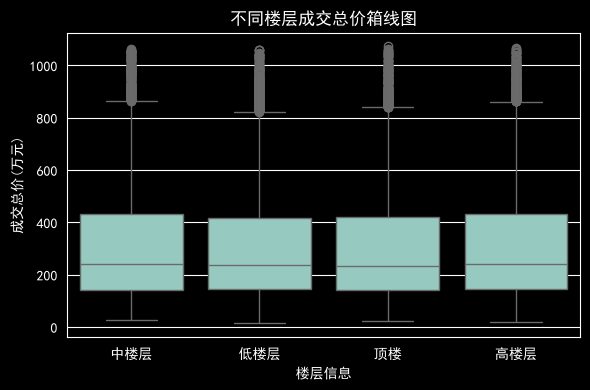

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,x='楼层信息',y='成交总价(万元)')
plt.title('不同楼层成交总价箱线图')
plt.tight_layout()
plt.show()

### 图注：不同楼层房屋成交总价箱线图。箱体代表四分位区间，上下须为正常样本边界，圆点代表异常值。对比四类楼层房价分布，各类楼层房价中位数差距不大，但均存在高价异常房源；后续使用IQR规则剔除这类离群样本。

## 使用IQR方法剔除房价离群点

原始清洗后行数: 19013
剔除房价离群点后行数: 18228
剔除异常样本数量: 785


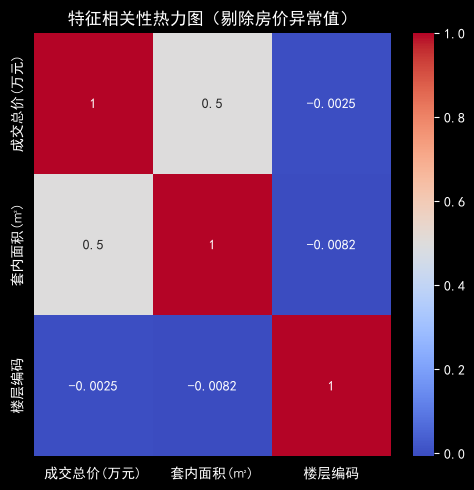

In [16]:
# 先计算四分位数、IQR、上下边界
Q1 = df['成交总价(万元)'].quantile(0.25)
Q3 = df['成交总价(万元)'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR   # 异常下限
upper_bound = Q3 + 1.5 * IQR   # 异常上限

#筛选保留正常范围数据
df_clean = df[(df['成交总价(万元)'] >= lower_bound) & (df['成交总价(万元)'] <= upper_bound)]

print(f"原始清洗后行数: {len(df)}")
print(f"剔除房价离群点后行数: {len(df_clean)}")
print(f"剔除异常样本数量: {len(df)-len(df_clean)}")

#画热力图（使用剔除离群点后的干净数据）
corr_matrix = df_clean[['成交总价(万元)','套内面积(㎡)','楼层编码']].corr()
plt.figure(figsize=(5,5))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.title('特征相关性热力图（剔除房价异常值）')
plt.tight_layout()
plt.show()

### 图为清洗并剔除房价异常样本后的调整皮尔逊相关热力图，颜色越红代表正相关性越强，颜色越蓝代表负相关性越强。结果可见套内面积与成交总价存在中等程度正相关；楼层编码与房价、套内面积的相关系数趋近于零，不存在明显的线性相关关系。